# Real vs. synthetic sentiment distributions

Compares the **real** FABSA label distribution against the **planted** distribution in the
synthetic benchmark corpus, to document how far the synthetic generator's assumptions
depart from the data it is meant to stand in for.

- **Real** — `notebooks/clean_fabsa.csv`, grouped by `industry x child_aspect`; sentiment
  shares are the empirical proportions within each group.
- **Synthetic** — the most recent `benchmark_outputs/*_insights.csv`. Its `level == "org"`
  rows are the *independently sampled* splits from `benchmark_builder.ipynb`:
  `pos ~ U(0.20, 0.85)`, `neu ~ U(0.02, 0.06)`, `neg = 1 - pos - neu`.
  The `level == "industry"` rows are volume-weighted aggregates of those org rows, not
  fresh draws, so the sampled distribution is the org-level one.

Two figures are written to `figures/`:
1. `neg_share_real_vs_synthetic.png` — distribution of negative share across groups.
2. `group_size_real_vs_synthetic.png` — distribution of group sizes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

ROOT     = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FABSA    = ROOT / "notebooks" / "clean_fabsa.csv"
OUT_DIR  = ROOT / "benchmark_outputs"
FIG_DIR  = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# --- chart tokens (validated categorical slots 1-3; light surface) ---------------
C_REAL, C_SYN, C_BIG = "#2a78d6", "#eb6834", "#1baf7a"   # real / synthetic / real (n>=100)
SURFACE, GRID, AXIS = "#fcfcfb", "#e1e0d9", "#c3c2b7"
INK, INK_2, MUTED   = "#0b0b0b", "#52514e", "#898781"

plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 200,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
})

def style(ax, axis="y"):
    ax.grid(axis=axis, color=GRID, lw=0.8, ls="-", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

print("root:", ROOT)

root: c:\msc-cx-agent-bench


## 1. Real distribution — FABSA, grouped by industry x child_aspect

In [2]:
fabsa = pd.read_csv(FABSA)
print(f"{len(fabsa):,} aspect-level labels | "
      f"{fabsa.industry.nunique()} industries | {fabsa.child_aspect.nunique()} child aspects")
print("overall sentiment mix:",
      fabsa.sentiment.value_counts(normalize=True).round(3).to_dict())

# one row per (industry, child_aspect): sentiment shares + group size
ct = pd.crosstab([fabsa.industry, fabsa.child_aspect], fabsa.sentiment)
for s in ("positive", "negative", "neutral"):
    if s not in ct.columns:
        ct[s] = 0
real = (ct[["positive", "negative", "neutral"]]
        .div(ct.sum(axis=1), axis=0)
        .rename(columns={"positive": "pos_share", "negative": "neg_share",
                         "neutral": "neu_share"}))
real["n"] = ct.sum(axis=1)
real = real.reset_index()

print(f"\nreal groups (industry x child_aspect): {len(real)} "
      f"(of {fabsa.industry.nunique() * fabsa.child_aspect.nunique()} possible - "
      f"the grid is sparse)")
real.head()

13,998 aspect-level labels | 10 industries | 12 child aspects
overall sentiment mix: {'positive': 0.652, 'negative': 0.312, 'neutral': 0.036}

real groups (industry x child_aspect): 91 (of 120 possible - the grid is sparse)


sentiment,industry,child_aspect,pos_share,neg_share,neu_share,n
0,Banking,account-access,0.056000,0.632000,0.312000,125
1,Banking,app-website,0.485149,0.274752,0.240099,404
2,Banking,attitude-of-staff,0.141414,0.848485,0.010101,99
3,Banking,competitor,0.867347,0.132653,0.000000,98
4,Banking,discounts-promotions,0.125000,0.875000,0.000000,8


saved figures\fabsa_aspect_distribution.png
top 3 aspects = ['app-website', 'general-satisfaction', 'ease-of-use'] -> 63.8% of labels
bottom 3 aspects -> 3.4% of labels


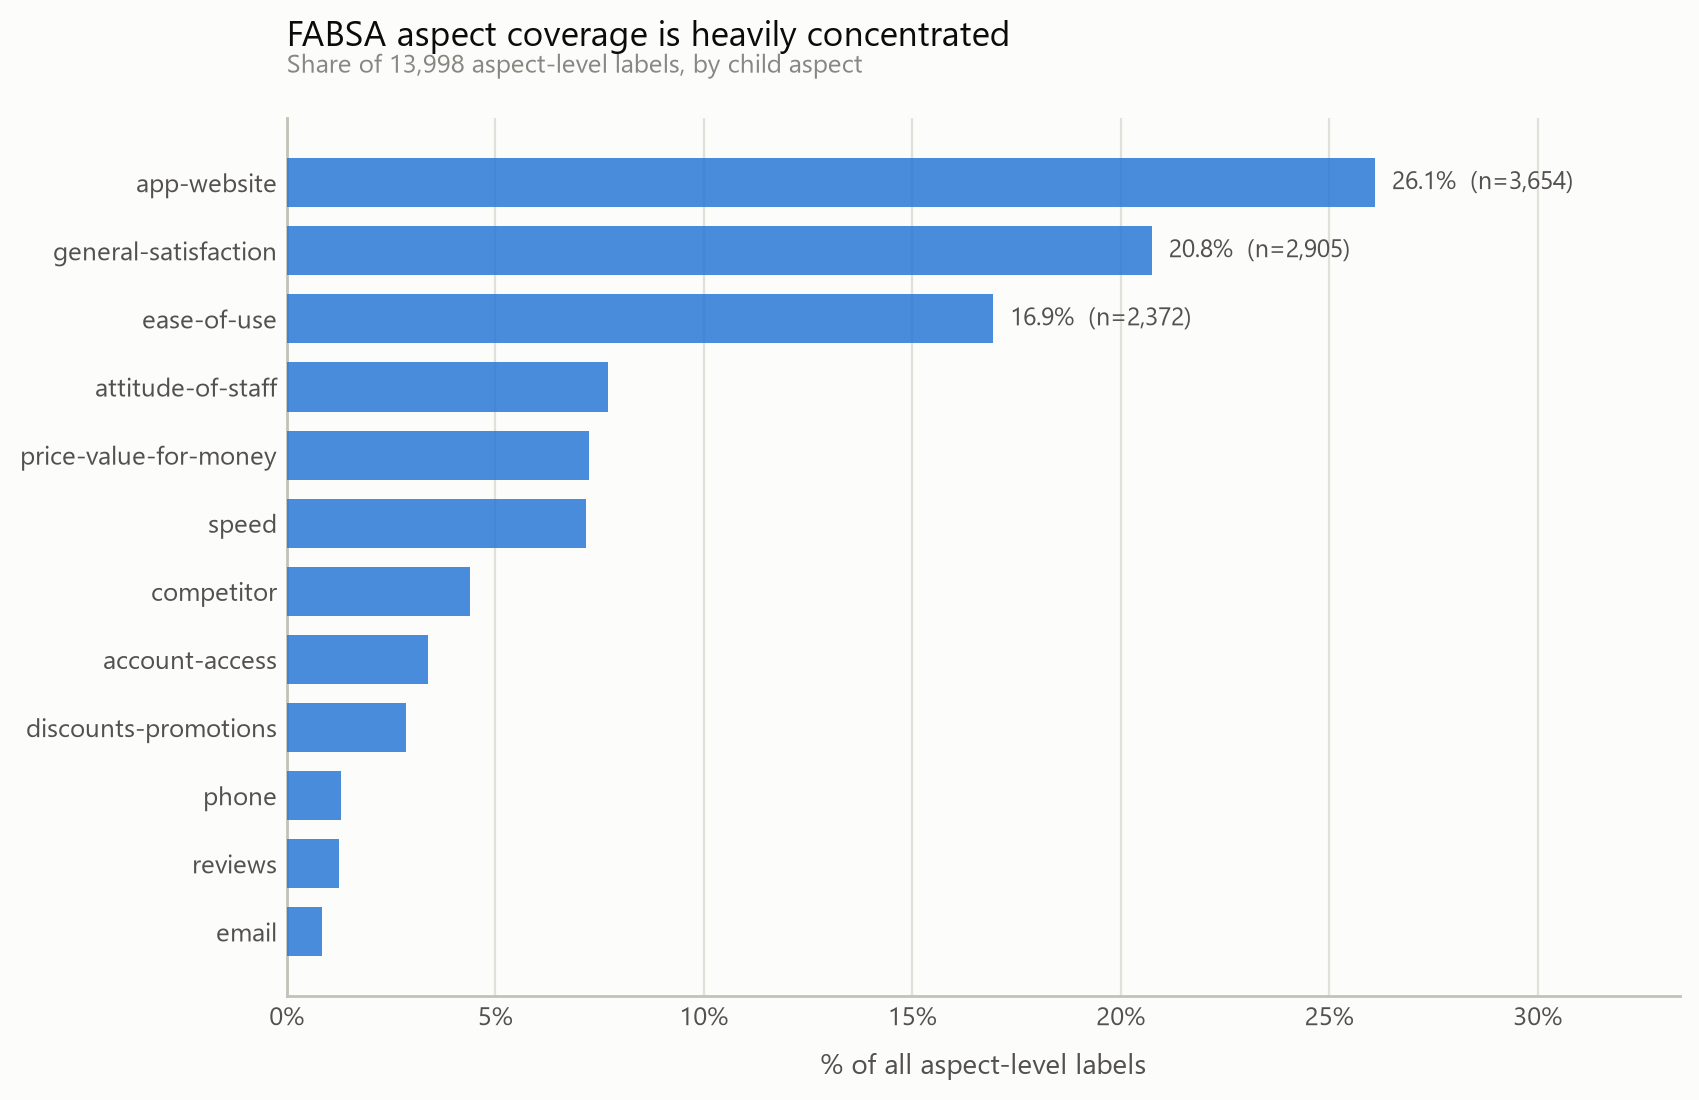

In [3]:
# Aspect distribution — how FABSA's 13,998 labels split across the 12 child aspects.
# Single series, so no legend (the title names it) and a single hue: orange stays
# reserved for "synthetic" in the section 4 figures.
asp = fabsa.child_aspect.value_counts()
asp_pct = asp / asp.sum() * 100
order = asp_pct.sort_values()                     # ascending -> largest lands at the top of barh

fig, ax = plt.subplots(figsize=(8.6, 5.6))
style(ax, axis="x")

ax.barh(order.index, order.values, height=0.72, color=C_REAL, alpha=0.85, zorder=3)

# selective direct labels: the three that dominate the corpus
for name in order.index[-3:]:
    ax.text(order[name] + 0.4, name, f"{order[name]:.1f}%  (n={asp[name]:,})",
            va="center", ha="left", color=INK_2, fontsize=9)

ax.set_xlim(0, order.max() * 1.28)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("% of all aspect-level labels", color=INK_2, fontsize=10, labelpad=8)
ax.set_title("FABSA aspect coverage is heavily concentrated",
             color=INK, fontsize=12.5, loc="left", pad=26)
ax.text(0, 1.045, f"Share of {len(fabsa):,} aspect-level labels, by child aspect",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")

fig.tight_layout()
out_c = FIG_DIR / "fabsa_aspect_distribution.png"
fig.savefig(out_c, bbox_inches="tight")
print("saved", out_c.relative_to(ROOT))
print(f"top 3 aspects = {order.index[-3:][::-1].tolist()} -> {order.iloc[-3:].sum():.1f}% of labels")
print(f"bottom 3 aspects -> {order.iloc[:3].sum():.1f}% of labels")
plt.show()

saved figures\fabsa_sentiment_distribution.png
corpus-level negative share = 0.312  (the figure section 3 compares against the synthetic plant)


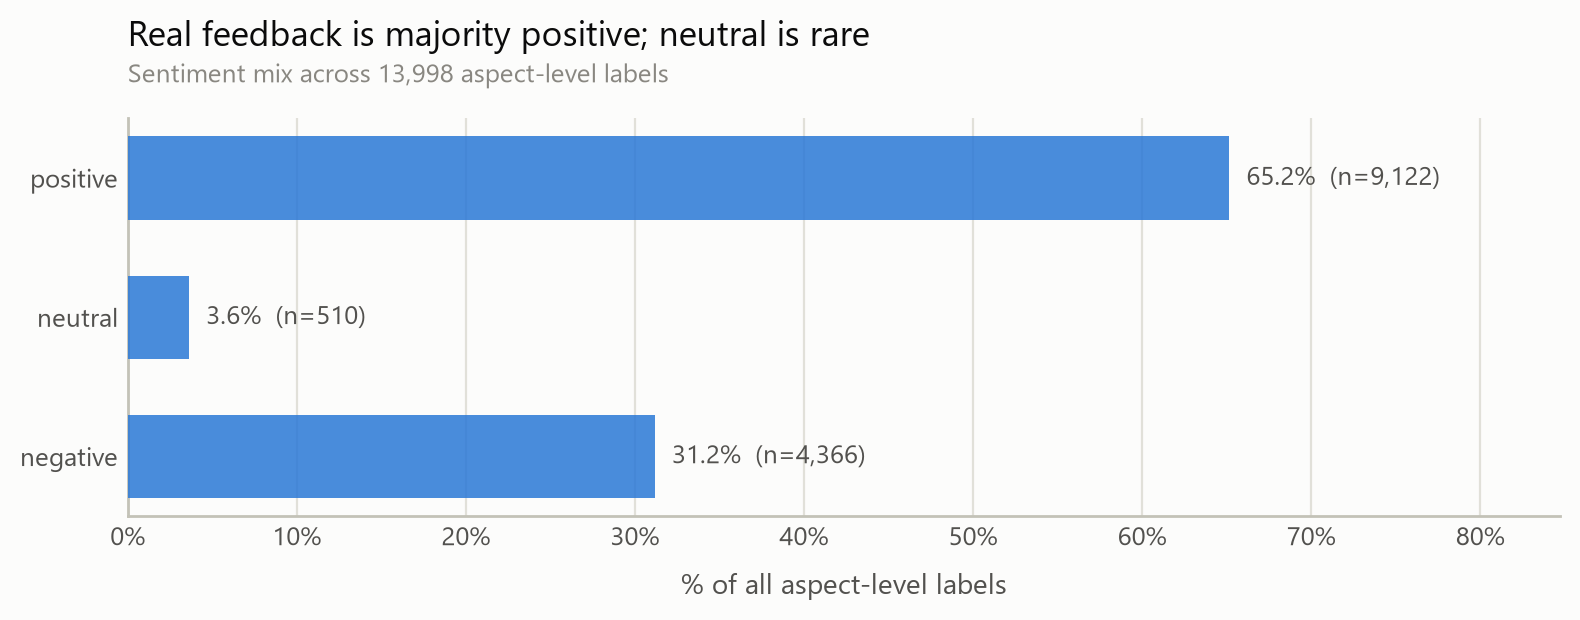

In [4]:
# Sentiment distribution — the overall label mix. Ordered by polarity (positive -> negative)
# rather than by size, so the shape is readable at a glance. Same single hue as above.
sent = fabsa.sentiment.value_counts().reindex(["positive", "neutral", "negative"])
sent_pct = sent / sent.sum() * 100

fig, ax = plt.subplots(figsize=(8.0, 3.2))
style(ax, axis="x")

ax.barh(sent_pct.index[::-1], sent_pct.values[::-1], height=0.6,
        color=C_REAL, alpha=0.85, zorder=3)
for name in sent_pct.index:
    ax.text(sent_pct[name] + 1.0, name, f"{sent_pct[name]:.1f}%  (n={sent[name]:,})",
            va="center", ha="left", color=INK_2, fontsize=9.5)

ax.set_xlim(0, sent_pct.max() * 1.30)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("% of all aspect-level labels", color=INK_2, fontsize=10, labelpad=8)
ax.set_title("Real feedback is majority positive; neutral is rare",
             color=INK, fontsize=12.5, loc="left", pad=26)
ax.text(0, 1.075, f"Sentiment mix across {len(fabsa):,} aspect-level labels",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")

fig.tight_layout()
out_d = FIG_DIR / "fabsa_sentiment_distribution.png"
fig.savefig(out_d, bbox_inches="tight")
print("saved", out_d.relative_to(ROOT))
print(f"corpus-level negative share = {sent_pct['negative'] / 100:.3f}  "
      f"(the figure section 3 compares against the synthetic plant)")
plt.show()

## 2. Synthetic distribution — most recent planted `*_insights.csv`

In [5]:
insights_path = max(OUT_DIR.glob("*_insights.csv"), key=lambda p: p.name)
syn = pd.read_csv(insights_path)
print("using:", insights_path.name)
print(syn.level.value_counts().to_dict())

syn_org = syn[syn.level == "org"].copy()        # the U(0.20, 0.85) draws
syn_ind = syn[syn.level == "industry"].copy()   # volume-weighted aggregates of the above

print(f"\norg-level groups (sampled):    {len(syn_org)}  "
      f"[{syn_org.industry.nunique()} industries x {syn_org.org.nunique()} orgs "
      f"x {syn_org.child_aspect.nunique()} aspects]")
print(f"industry-level groups (derived): {len(syn_ind)}")
syn_org.head()

using: 2026-07-28_174308_insights.csv
{'org': 240, 'industry': 120}

org-level groups (sampled):    240  [10 industries x 20 orgs x 12 aspects]
industry-level groups (derived): 120


,group_id,level,industry,org,child_aspect,pos_share,neg_share,neu_share,n
0,G0001,org,Banking,BankA,account-access,0.26,0.72,0.02,52
1,G0002,org,Banking,BankA,competitor,0.29,0.66,0.05,52
2,G0003,org,Banking,BankA,general-satisfaction,0.74,0.23,0.03,52
3,G0004,org,Banking,BankA,reviews,0.49,0.46,0.05,52
4,G0005,org,Banking,BankA,speed,0.41,0.57,0.02,52


## 3. Side-by-side summary

`syn (org)` is the sampled distribution and the primary comparison; `syn (industry)` is shown
to make the granularity difference explicit — those rows are averages of the org rows, so they
are mechanically narrower and are *not* independent draws.

In [6]:
def describe(df, label):
    return pd.Series({
        "groups":      len(df),
        "neg mean":    df.neg_share.mean(),
        "neg median":  df.neg_share.median(),
        "neg sd":      df.neg_share.std(),
        "neg min":     df.neg_share.min(),
        "neg max":     df.neg_share.max(),
        "pos mean":    df.pos_share.mean(),
        "neu mean":    df.neu_share.mean(),
        "n median":    df.n.median(),
        "n min":       df.n.min(),
        "n max":       df.n.max(),
    }, name=label)

real_big = real[real.n >= 100]
summary = pd.concat([describe(real, "real (all 91)"),
                     describe(real_big, "real (n>=100)"),
                     describe(syn_org, "syn (org)"),
                     describe(syn_ind, "syn (industry)")], axis=1).round(3)
print(summary.to_string())

# unweighted per-group means give tiny groups equal footing; volume-weighted is the
# corpus-level truth, and the fairer number to compare against a planted mean.
vw_real = (real.neg_share * real.n).sum() / real.n.sum()
vw_syn  = (syn_org.neg_share * syn_org.n).sum() / syn_org.n.sum()
print(f"\nvolume-weighted negative share -- real: {vw_real:.3f} | synthetic: {vw_syn:.3f}")

lo, hi = syn_org.neg_share.min(), syn_org.neg_share.max()
print(f"synthetic neg_share support: [{lo:.2f}, {hi:.2f}]")
print(f"real groups outside that support: {((real.neg_share < lo) | (real.neg_share > hi)).mean():.1%}")
print(f"real groups with n < 30 (noisy shares): {(real.n < 30).mean():.1%}")
print(f"real groups sitting at exactly 0.0 or 1.0: {((real.neg_share == 0) | (real.neg_share == 1)).sum()}"
      f"  (max size among them: {real.loc[(real.neg_share == 0) | (real.neg_share == 1), 'n'].max()})")

            real (all 91)  real (n>=100)  syn (org)  syn (industry)
groups             91.000         37.000    240.000         120.000
neg mean            0.485          0.294      0.426           0.426
neg median          0.412          0.275      0.440           0.408
neg sd              0.314          0.167      0.188           0.149
neg min             0.000          0.017      0.110           0.130
neg max             1.000          0.809      0.760           0.730
pos mean            0.423          0.659      0.533           0.533
neu mean            0.092          0.047      0.041           0.041
n median           75.000        338.000     52.000         104.000
n min               3.000        104.000     52.000         104.000
n max            1024.000       1024.000     52.000         104.000

volume-weighted negative share -- real: 0.312 | synthetic: 0.426
synthetic neg_share support: [0.11, 0.76]
real groups outside that support: 37.4%
real groups with n < 30 (noisy share

## 4a. Figure — negative share, real vs synthetic

Series are normalised to *% of groups* so the shapes stay comparable despite the different
group counts. A third series — real groups with `n >= 100` — is included because ~31% of real
groups have fewer than 30 reviews, and those thin groups produce share estimates pinned at 0.0
or 1.0 that are sampling noise rather than genuinely one-sided aspects.

saved figures\neg_share_real_vs_synthetic.png


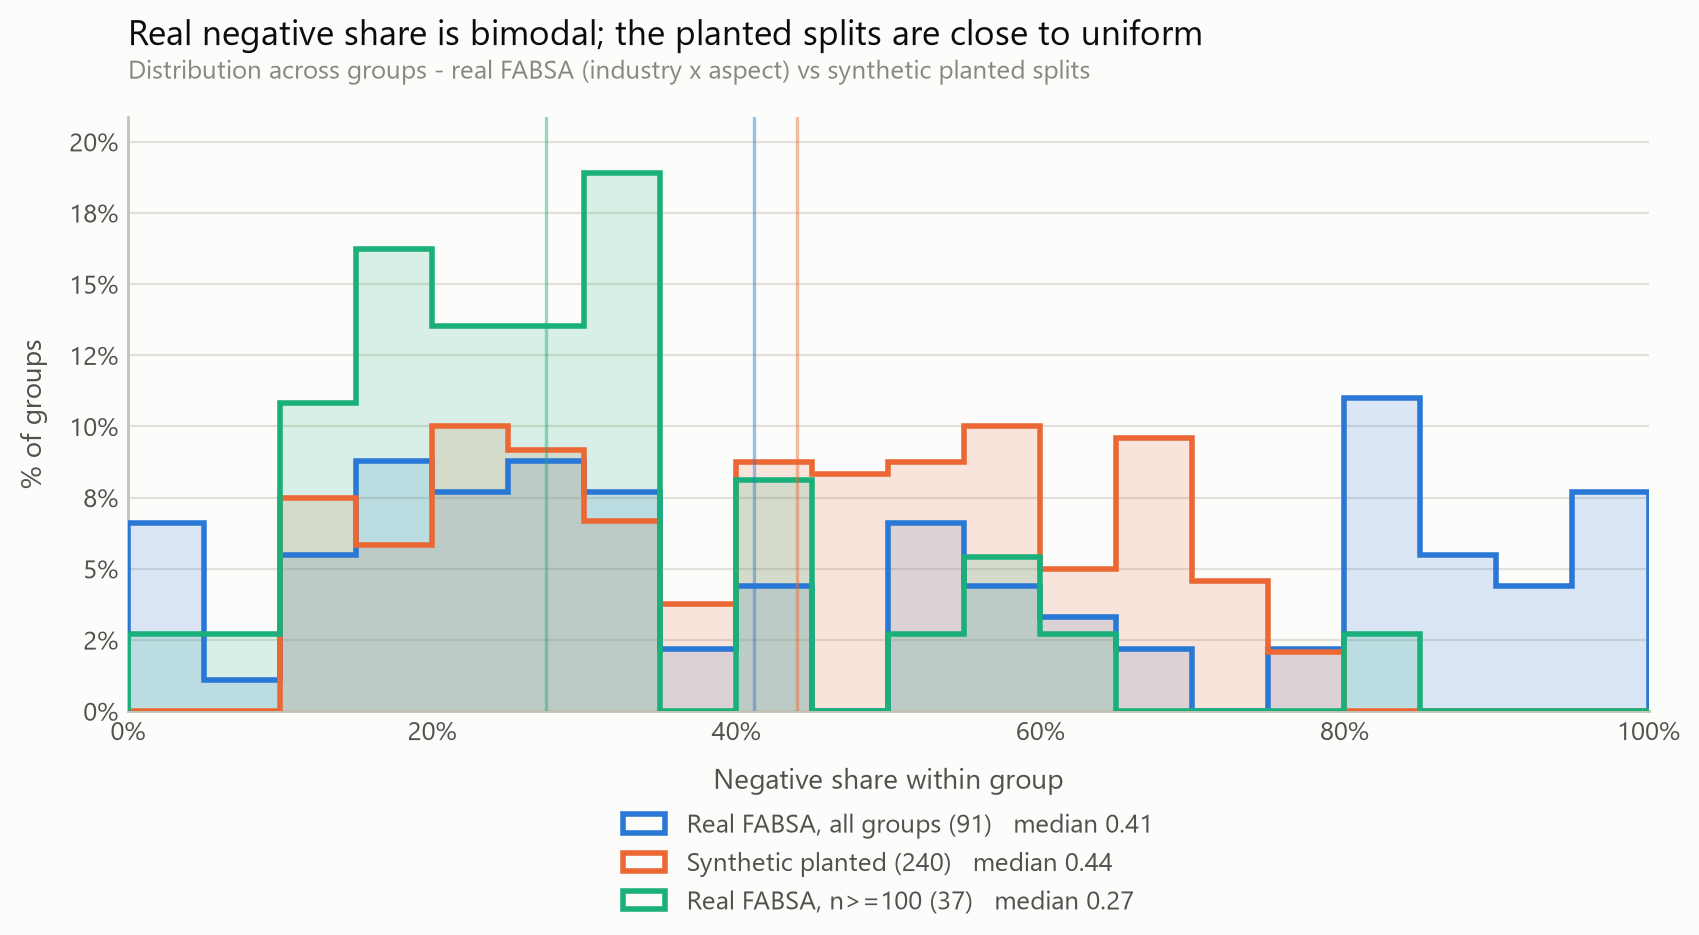

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 4.9))
style(ax)

bins = np.arange(0, 1.0001, 0.05)
# medians ride in the legend labels: the three sit too close on the x-axis to be
# text-annotated in place without colliding.
series = [
    (real.neg_share,     C_REAL, f"Real FABSA, all groups ({len(real)})   median {real.neg_share.median():.2f}"),
    (syn_org.neg_share,  C_SYN,  f"Synthetic planted ({len(syn_org)})   median {syn_org.neg_share.median():.2f}"),
    (real_big.neg_share, C_BIG,  f"Real FABSA, n>=100 ({len(real_big)})   median {real_big.neg_share.median():.2f}"),
]
for data, colour, label in series:
    w = np.full(len(data), 100 / len(data))
    ax.hist(data, bins=bins, weights=w, color=colour, alpha=0.16, zorder=2)
    ax.hist(data, bins=bins, weights=w, histtype="step", color=colour, lw=2.0,
            label=label, zorder=3)

ax.set_xlim(0, 1)
ax.set_ylim(0, ax.get_ylim()[1] * 1.05)
for data, colour, _ in series:
    ax.axvline(data.median(), color=colour, lw=1.2, alpha=0.45, zorder=4)

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("Negative share within group", color=INK_2, fontsize=10, labelpad=8)
ax.set_ylabel("% of groups", color=INK_2, fontsize=10, labelpad=8)
ax.set_title("Real negative share is bimodal; the planted splits are close to uniform",
             color=INK, fontsize=12.5, loc="left", pad=26)
ax.text(0, 1.055,
        "Distribution across groups - real FABSA (industry x aspect) vs synthetic planted splits",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")
ax.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, ncol=1,
          loc="upper center", bbox_to_anchor=(0.5, -0.15), handlelength=1.6,
          columnspacing=1.4, borderpad=0)

fig.tight_layout()
out_a = FIG_DIR / "neg_share_real_vs_synthetic.png"
fig.savefig(out_a, bbox_inches="tight")
print("saved", out_a.relative_to(ROOT))
plt.show()

## 4b. Figure — group sizes, real vs synthetic

Log x-axis: real group sizes span three orders of magnitude, the synthetic ones do not vary
at all (the builder's proportional top-up collapses to the same bonus for every group).

saved figures\group_size_real_vs_synthetic.png


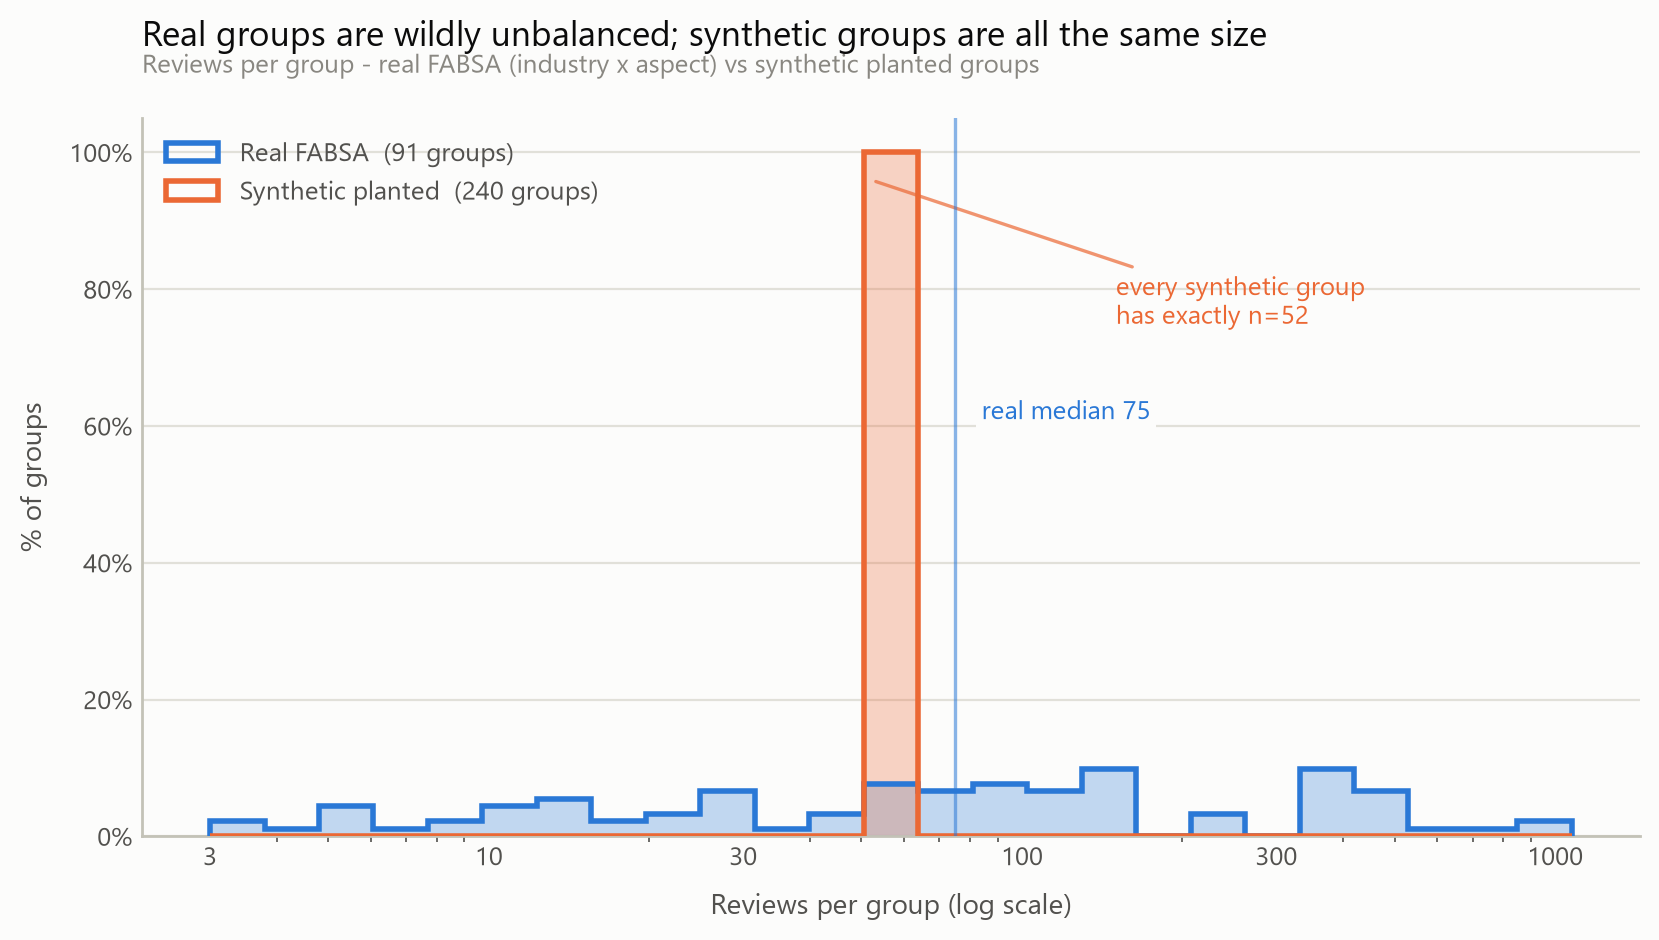

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
style(ax)

lo_n = min(real.n.min(), syn_org.n.min())
hi_n = max(real.n.max(), syn_org.n.max())
bins = np.logspace(np.log10(max(lo_n, 1)), np.log10(hi_n * 1.05), 26)

for data, colour, label in ((real.n, C_REAL, f"Real FABSA  ({len(real)} groups)"),
                            (syn_org.n, C_SYN, f"Synthetic planted  ({len(syn_org)} groups)")):
    w = np.full(len(data), 100 / len(data))
    ax.hist(data, bins=bins, weights=w, color=colour, alpha=0.28, zorder=2)
    ax.hist(data, bins=bins, weights=w, histtype="step", color=colour, lw=2.0,
            label=label, zorder=3)

ax.set_xscale("log")
ax.set_xticks([3, 10, 30, 100, 300, 1000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("Reviews per group (log scale)", color=INK_2, fontsize=10, labelpad=8)
ax.set_ylabel("% of groups", color=INK_2, fontsize=10, labelpad=8)

# selective direct labels: the synthetic spike and the real median
ax.annotate(f"every synthetic group\nhas exactly n={int(syn_org.n.iloc[0])}",
            xy=(syn_org.n.iloc[0], 96), xytext=(150, 78),
            color=C_SYN, fontsize=9.5, ha="left", va="center",
            arrowprops=dict(arrowstyle="-", color=C_SYN, lw=1.2, alpha=0.7))
ax.axvline(real.n.median(), color=C_REAL, lw=1.2, alpha=0.55, zorder=4)
ax.text(real.n.median() * 1.12, 62, f"real median {int(real.n.median())}",
        color=C_REAL, ha="left", va="center", fontsize=9.5,
        bbox=dict(fc=SURFACE, ec="none", pad=2))

ax.set_title("Real groups are wildly unbalanced; synthetic groups are all the same size",
             color=INK, fontsize=12.5, loc="left", pad=26)
ax.text(0, 1.055, "Reviews per group - real FABSA (industry x aspect) vs synthetic planted groups",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")
ax.legend(frameon=False, loc="upper left", fontsize=9.5, labelcolor=INK_2)

fig.tight_layout()
out_b = FIG_DIR / "group_size_real_vs_synthetic.png"
fig.savefig(out_b, bbox_inches="tight")
print("saved", out_b.relative_to(ROOT))
plt.show()

## 5. What the comparison shows

**Negative share — shape, not spread, is the real gap.** The honest summary is more nuanced
than "synthetic is flatter":

- *Shape.* The real distribution is **bimodal** — a dominant mode around 0.15–0.30 plus a
  second cluster up at 0.80–1.00. The planted splits are close to **uniform** over their
  support, which is exactly what the generator specifies: `pos ~ U(0.20, 0.85)` with
  `neu ~ U(0.02, 0.06)` makes `neg = 1 - pos - neu` approximately uniform on `[0.09, 0.78]`.
  Real groups differ from one another in a *structured* way — some aspects are reliably
  complaint-heavy — whereas synthetic groups differ only by an independent draw.
- *Spread.* Across all 91 real groups the standard deviation (0.314) is **larger** than the
  synthetic one (0.188), so the synthetic set is not simply "flatter". But much of that extra
  real spread is small-group noise: 12 real groups sit at exactly 0.0 or 1.0 and all but one
  have fewer than 30 reviews. Restricted to `n >= 100`, real spread falls to 0.167 — now
  *narrower* than synthetic. Which of the two is "wider" therefore depends entirely on the
  minimum-group-size threshold, and should be stated with one.
- *Level.* Per-group unweighted means are close (real 0.485 vs synthetic 0.426), but that
  statistic gives a 3-review group the same weight as a 1,024-review one. Volume-weighted, the
  real corpus is 0.312 negative against a synthetic 0.426 — so the synthetic corpus does
  materially **over-state negativity** at the corpus level, by roughly 11 percentage points.

**Group size.** Real groups span 3 to 1,024 reviews and are heavily right-skewed (median 75).
Every synthetic group has *identical* size. That is not a modelling choice but an artefact:
the builder floors each group at `MIN_PER_GROUP = 50` and then distributes the leftover budget
proportionally to a `randint(45, 65)` draw — but with 240 groups against a 12,500 budget the
floor already consumes 12,000, so the remaining 500 rounds to the same +2 bonus for every
group. Widening `MAX_REVIEWS` or lowering the floor would restore the variation the draw was
meant to introduce.

**Why this matters for the benchmark.** Two task types lean on precisely what has been
flattened:

- *Prioritisation* (`priority = norm(volume) + norm(neg_share)`) is meant to trade volume off
  against negativity. With constant group size the volume term is constant, `norm(volume)` is
  degenerate, and prioritisation collapses into ranking by negative share alone — removing the
  trade-off the task was designed to test.
- *Top-k / compare* tasks are easier than their real counterparts when negative shares are
  spread uniformly: candidates are separated by wider, more evenly-spaced gaps than the
  bimodal real distribution would ever produce, so near-ties — the cases that actually
  discriminate between agents — almost never arise.

**Caveats.**
- *Granularity differs.* Real groups are `industry x aspect` (91); the sampled synthetic groups
  are `industry x org x aspect` (240). The synthetic `industry`-level rows *are*
  `industry x aspect`, but they are volume-weighted aggregates of the org rows rather than
  independent draws — mechanically narrower (sd 0.149) — which is why they are not the primary
  comparison. Section 3 reports both.
- *Sparse grid.* Only 91 of 120 possible `industry x aspect` cells occur in FABSA at all, so
  the real "distribution" is itself over an incomplete grid.
- *The real tails are partly noise.* ~31% of real groups have `n < 30`. The `n >= 100` series
  is the safer basis for any claim about real spread.
